<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 19.05.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [938]:
versuchsnummer = "243"
versuchsname = "White_Noise" 
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [939]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_1a.pdf


/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_30K.pdf


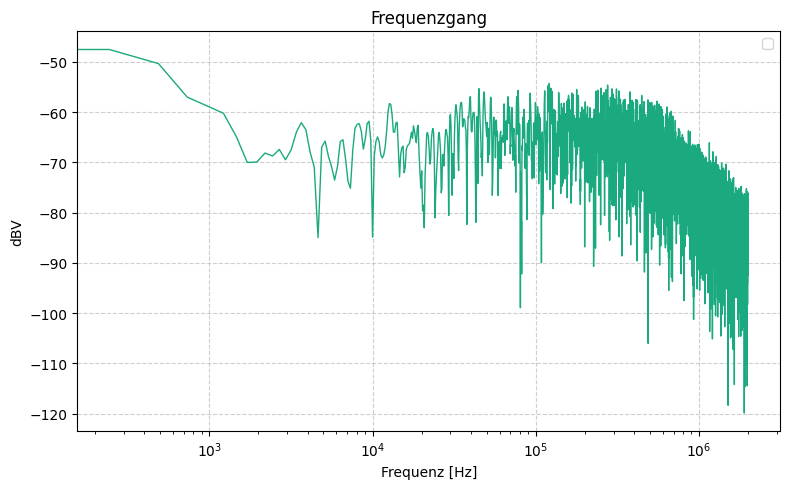

In [940]:
aufgabe = '1a'
pap.plot_general_csv("A1/5KOhm_FFT.csv", "Time (s)", "Channel 1 (V)", 
                 title="Frequenzgang", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf", show_plot=False)

aufgabe = '30K'
pap.plot_general_csv("A1/Spectrum_30k.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title="Frequenzgang", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_5K.pdf


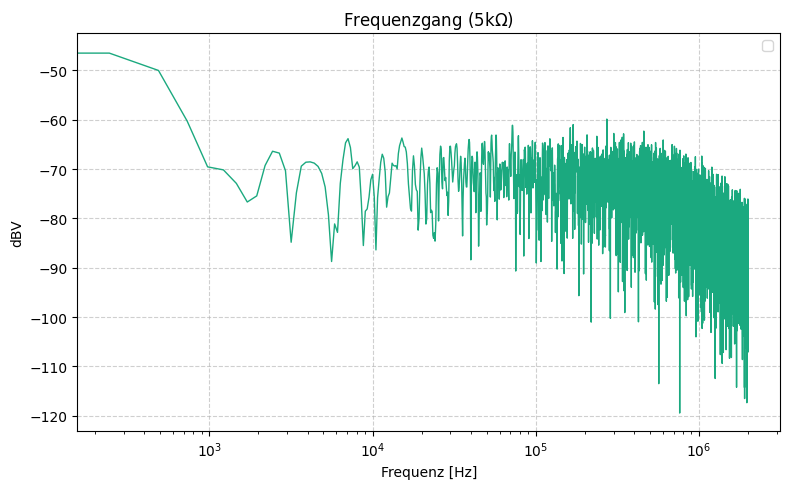

In [941]:
aufgabe = '5K'
pap.plot_general_csv("A1/Spectrum_5k.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title=fr"Frequenzgang (5k$\Omega$)", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_Bandfliter-5K.pdf


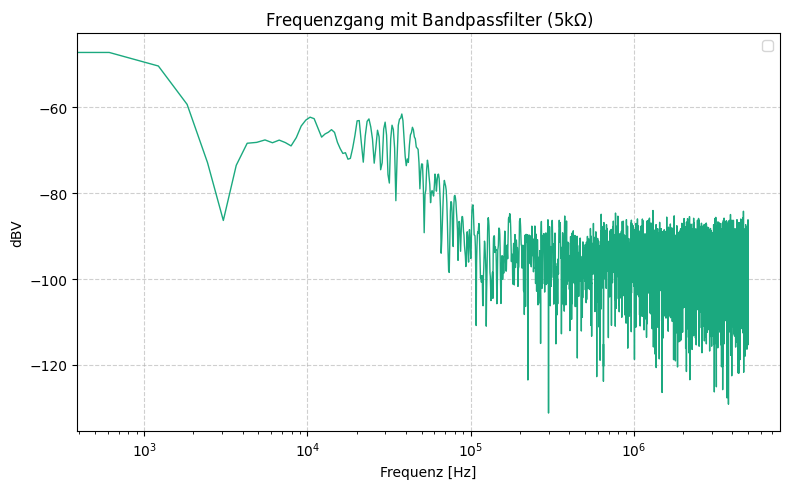

In [942]:
aufgabe = 'Bandfliter-5K'
pap.plot_general_csv("A1/Spectrum_5k_MitDASBandpassfilter.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title=fr"Frequenzgang mit Bandpassfilter (5k$\Omega$)", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

<hr>

## Aufgabe 2

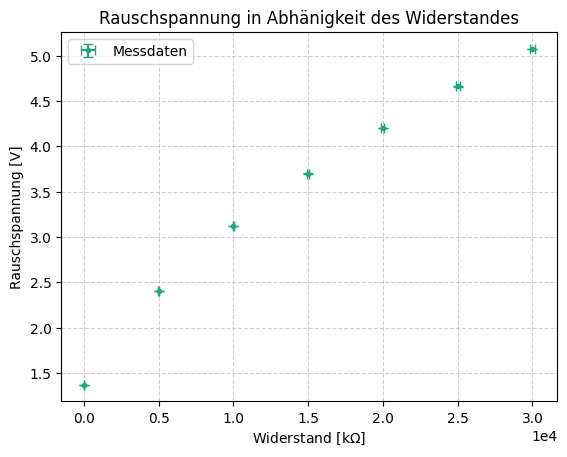

<Axes: title={'center': 'Rauschspannung in Abhänigkeit des Widerstandes'}, xlabel='Widerstand [$\\mathrm{k\\Omega}$]', ylabel='Rauschspannung [V]'>

In [943]:
aufgabe = '2a'
# Eintragen der Messdaten
n_messungen = 127

# Widerstände vo kOhm in Ohm
wid_stands = np.array([0, 5, 10, 15, 20, 25, 30]) * 1e3

# Spannung in V (oder in dBV?)
avg_Vr = np.array([1.3702, 2.4042, 3.1159, 3.6989, 4.201, 4.6594, 5.0751])
sig_Vr = np.array([0.0054, 0.0093, 0.011, 0.0149, 0.0147, 0.0173, 0.0188])
err_Vr = sig_Vr/np.sqrt(n_messungen)

# Fehler der Bauteile:
err_wid = 0.005 # pm 0.5% Fehler für Widerstände
err_vm = 0.003 # pm 0.3% Genauigkeit des Voltmeters


plt.errorbar(
    wid_stands, 
    avg_Vr, 
    err_Vr, 
    wid_stands * err_wid,
    label=fr'Messdaten', 
    fmt='.', 
    ls='',
    capsize=3.5
    )

pap.plot_me('Rauschspannung in Abhänigkeit des Widerstandes', r'Widerstand [$\mathrm{k\Omega}$]', r'Rauschspannung [V]', fr'{plt_save_folder}Spann_va_Wid_{aufgabe}')

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_2a.pdf


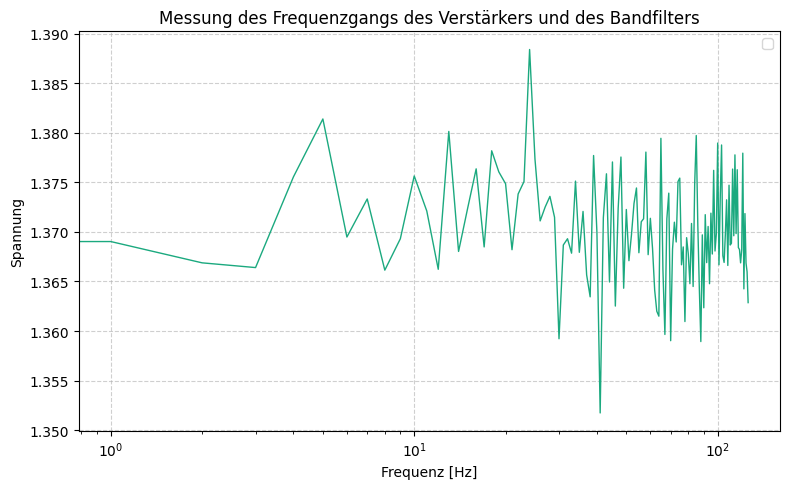

In [944]:
aufgabe = '2a'
pap.plot_general_csv("A2/0k.csv", "x000", "y000", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_2b.pdf


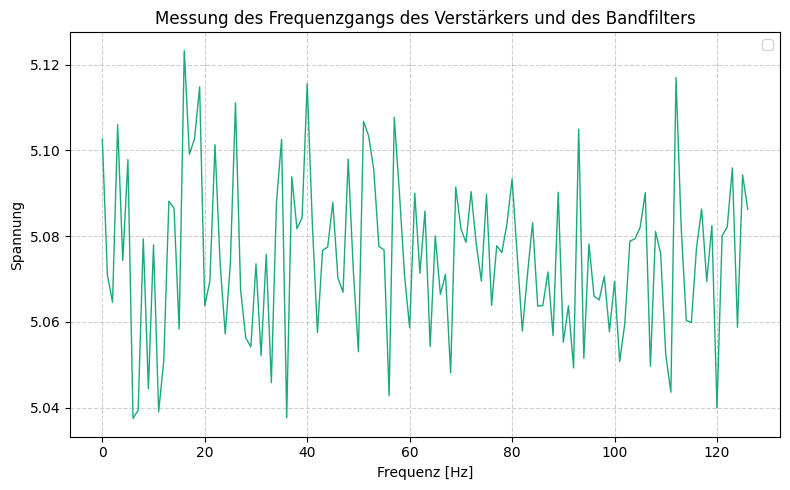

In [945]:
aufgabe = '2b'
pap.plot_general_csv("A2/30k.csv", "x000", "y000", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung", 
                 log_x=False, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

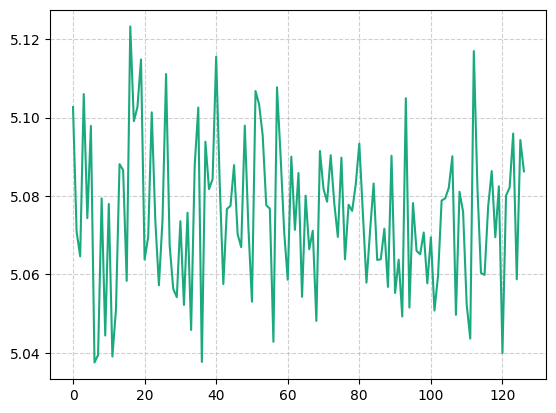

In [946]:
df = pd.read_csv("A2/30k.csv", comment='#', engine='python')
x_0 = df['x0000']
y_0 = df['y0000']
plt.plot(x_0, y_0)

<hr>

## Aufgabe 3

/home/anonymous/Documents/GitHub/PAP-2/Versuche/243/Python/Papulator.py:735: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Plot saved to ../img/plots/Frequenzgang_3a.pdf


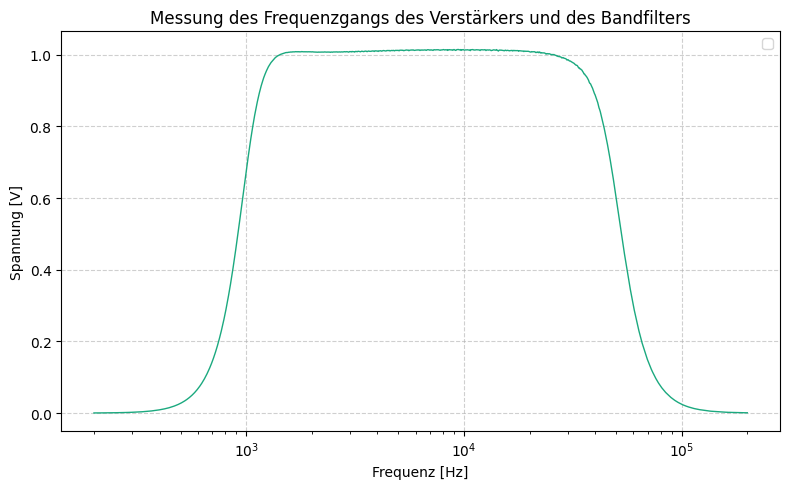

In [947]:
aufgabe = '3a'
pap.plot_general_csv("A3/Frequenzgang.csv", "Frequency (Hz)", "Channel 1 Magnitude (X)", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung [V]", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

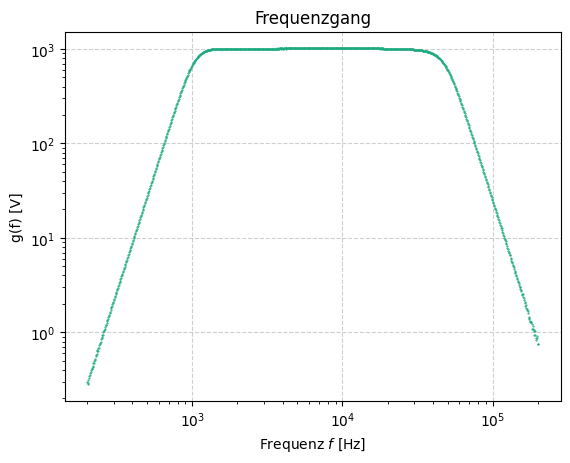

In [948]:
aufabe = '3c'
df = pd.read_csv("A3/Frequenzgang.csv", comment='#', engine='python')

# print(df)

freq_A3 = df['Frequency (Hz)']
gain_rho = df['Channel 1 Magnitude (X)']

damp = 0.001
err_damp = damp * 0.002 # 0.2%

g = gain_rho / damp

plt.loglog(freq_A3,g, linestyle='', marker='.', markersize=1)

# plt.axis([200, 2e5, 10, 1.5E3])
plt.xlabel('Frequenz $f$ [Hz]')
plt.ylabel('g(f) [V]')
plt.title('Frequenzgang')
plt.savefig(fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")
plt.show()

In [949]:
def fit_func(f,V,W1,W2,n1,n2):
    return V/(np.sqrt(1+1/(f/W1)**(2*n1))*np.sqrt(1+(f/W2)**(2*n2)))

In [967]:
# Fitparameter
# Versärkung:
ver = 1000

# Grenzfrequenzen
W1 = 1000 #Hz
W2 = 50000 #Hz

# Filterordnungen
n1, n2 = 5, 5

p0 = [ver, W1, W2, n1, n2]

popt, pcov = curve_fit(
    fit_func, 
    freq_A3, 
    g,
    p0)


print(fr'Die Verstärkung beträgt: {(pap.round_sig_digs(np.sqrt(pcov[0,0]), popt[0])[2])}')

U_ver = popt[0] * 1e-3
err_U_ver = np.sqrt(pcov[0,0]) *1e-1


Die Verstärkung beträgt: 1009.4 \pm 0.3


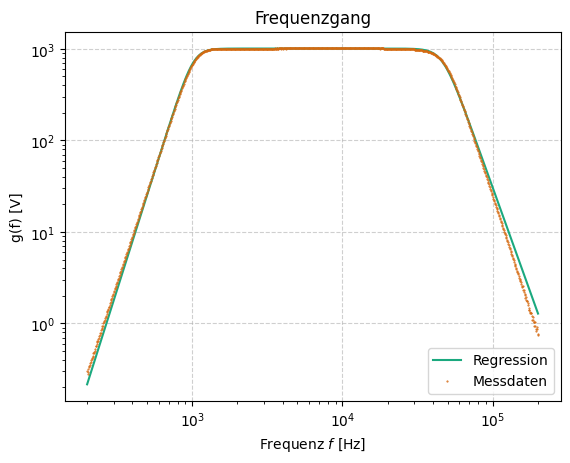

In [968]:
aufgabe ='Regression'

f = freq_A3
plt.loglog(
    f, 
    fit_func(f, *popt), 
    label='Regression'
    )

plt.loglog(
    f,
    g,
    linestyle='None', 
    marker='.',
    label='Messdaten',
    markersize=1
    )



# plt.axis([200, 2e5, 10, 1.5E3])

plt.xlabel('Frequenz $f$ [Hz]')
plt.ylabel('g(f) [V]')
plt.title('Frequenzgang')
plt.legend(loc='best')

plt.savefig(fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

In [969]:
def fit_func_square(f,V,W1,W2,n1,n2):
    return fit_func(f,V,W1,W2,n1,n2)**2

In [970]:
f = np.array(f)
B = quad(fit_func_square, f[0], f[len(f) - 1], args=tuple(popt))
print(fr'Das Integral betraegt: {pap.round_sig_digs(B[1], B[0])[2]}')
print(fr'{B[0]:.2g}')
print(fr'Der Prozentuale Fehler beträgt 2%, somit: {B[0]*0.02}')
print(fr'Das Integral betraegt: ({pap.round_sig_digs(B[0]*0.02 * 1e-10, B[0] * 1e-10)[2]}) * 10^10')


Das Integral betraegt: 47209654580 \pm 40
4.7e+10
Der Prozentuale Fehler beträgt 2%, somit: 944193091.6463813
Das Integral betraegt: (4.72 \pm 0.09) * 10^10


### Bestimmung der Boltzmannkonstanten

In [971]:
sym_U_aus, sym_U_V = sp.symbols(r'U_\text{aus}, U_\text{V}')
diff_func = sym_U_aus**2 - sym_U_V**2



values = np.column_stack([
    avg_Vr[1:], err_Vr[1:],
    [U_ver] * len(avg_Vr[1:]), [err_U_ver] * len(avg_Vr[1:])
])

res = pap.do_it(diff_func, [sym_U_aus, sym_U_V], values, [], False)

U_diff = res[:,0]
err_U_diff = res[:,1]

for i in range(6):
    print(pap.round_sig_digs(err_U_diff[i], U_diff[i])[2])

4.76 \pm 0.05
8.69 \pm 0.05
12.66 \pm 0.05
16.63 \pm 0.05
20.69 \pm 0.05
24.74 \pm 0.06


In [972]:
def linear(a,x):
    return a * x

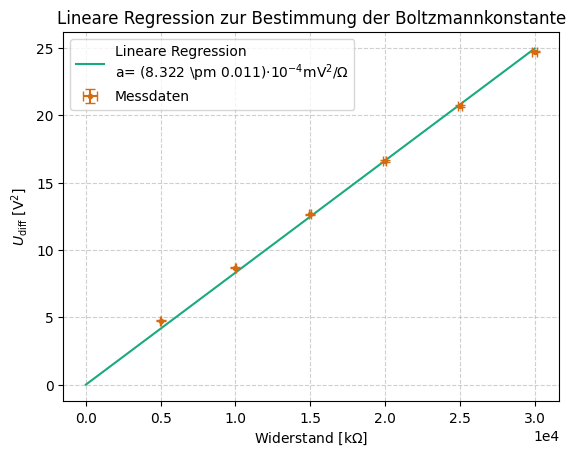

<Axes: title={'center': 'Lineare Regression zur Bestimmung der Boltzmannkonstante'}, xlabel='Widerstand [$\\mathrm{k\\Omega}$]', ylabel='$U_\\text{diff}$ [V$^2$]'>

In [973]:
aufgabe = 'liest_das_hier_irgendwer'
popt_lin, pcov_lin= curve_fit(linear, wid_stands[1:], U_diff, sigma=err_U_diff, absolute_sigma=True)
steig= popt_lin[0]
err_steig = np.sqrt(pcov_lin[0, 0])

plt.plot(
    wid_stands, 
    linear(wid_stands, *popt_lin),
    label=f'Lineare Regression\na= ({pap.round_sig_digs(err_steig * 1e4, steig * 1e4)[2]})' r'$ \cdot 10^{-4} \mathrm{mV^2/\Omega}$'
    )

plt.errorbar(
    wid_stands[1:], 
    U_diff, 
    err_U_diff, 
    wid_stands[1:] * err_wid,
    label=fr'Messdaten', 
    fmt='.', 
    ls='',
    capsize=3.5
    )

pap.plot_me('Lineare Regression zur Bestimmung der Boltzmannkonstante', r'Widerstand [$\mathrm{k\Omega}$]', r'$U_\text{diff}$ [V$^2$]', fr'{plt_save_folder}lin_reg_{aufgabe}')

In [974]:
chisquare=np.sum(((linear(wid_stands[1:],*popt_lin)-U_diff)**2/err_U_diff**2))
dof=5
chisquare_red=chisquare/dof
print(chisquare_red)

print(chi2.cdf(chisquare, dof))

prob = round((1 - chi2.cdf(chisquare, dof)) * 100, 2)

print("Wahrscheinlichkeit=" + str(prob) + "%")

42.34991696745277
1.0
Wahrscheinlichkeit=0.0%


In [975]:
func_k_b = sym.a / (sym.B * 4 * sym.T * sym.R * sym.D**2)

values = np.array([
    steig, err_steig,
    B[0], B[0]* 0.02,
    22.3 + 273.15, 0.3,
    ver, ver * 0.02,
    const.R
])
k_b = pap.do_it(func_k_b, [sym.a, sym.B, sym.T, sym.D, sym.R], values, [sym.R], False)

val_k_b = k_b[0][0]
err_k_b = k_b[0][1]

print(fr'({k_b[0][0] * 1e+23:.3g} \pm {k_b[0][1] * 1e+23:.1g}) 10^-23 J/K')

print(pap.round_sig_digs(k_b[0][1], k_b[0][0])[2])

(0.179 \pm 0.008) 10^-23 J/K
0.00000000000000000000000179 \pm 0.00000000000000000000000008


In [976]:
values = np.array([
    steig * 1e-3, err_steig * 1e-3, 
    B[0] / 100,
    22.3 + 273.15, 0.3,
    ver, ver * 0.02,
    const.R
])

k_b_stat = pap.do_it(func_k_b, [sym.a, sym.B, sym.T, sym.D, sym.R], values, [sym.R, sym.B], False)

print(fr'Statistischer Fehler:{k_b_stat[0][1]:.2g}')


values = np.array([
    steig * 1e-3,
    B[0] , B[0]* 0.02,
    22.3 + 273.15,
    ver,
    const.R
])

k_b_sys = pap.do_it(func_k_b, [sym.a, sym.B, sym.T, sym.D, sym.R], values, [sym.a, sym.T, sym.D, sym.R], False)
print(fr'Systemischer Fehler:{k_b_sys[0][1]:.2g}')

print(fr'Gesamt Fehler: {np.sqrt(k_b_sys[0][1]**2 + k_b_stat[0][1]**2):.2g}')


Statistischer Fehler:7.2e-27
Systemischer Fehler:3.6e-29
Gesamt Fehler: 7.2e-27


In [977]:
print(pap.std_abw(val_k_b, const.k_B, err_k_b))
print(const.k_B)

149.61
1.380649e-23


<hr>

## Aufgabe 4

Plot saved to ../img/plots/Frequenzgang_4a.pdf


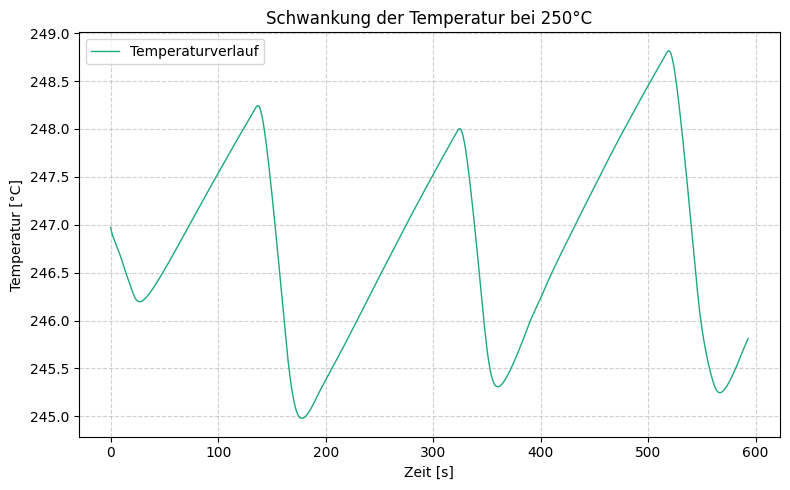

In [978]:
aufgabe = '4a'
pap.plot_general_csv("A4/Schwankung_der_Temperatur_250C.csv", "x000", "y000", 
                 title=fr"Schwankung der Temperatur bei 250°C", xlabel="Zeit [s]", ylabel="Temperatur [°C]", 
                 log_x=False, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf",label='Temperaturverlauf')

In [979]:
# Import der Messdaten
temp_theo = np.array([50, 100, 150, 200, 250])
avg_Ur_t = np.array([2.4511, 2.7238, 3.0058, 3.297, 3.6351])
sig_Ur_t = np.array([0.00922, 0.0113, 0.0115, 0.0132, 0.0135])

T_1 = np.array([52.6, 97.7, 144.8, 188.4, 247.3]) +273.15
R_1 = np.array([4.8288, 5.5496, 6.3121, 7.027, 8.033])

$\frac{(U^{2}_{aus} - U^{2}_{V})}{R} = c^{\prime}T$

$\frac{(U^{2}_{aus} - U^{2}_{V})}{R} = (4 k_B B)T$

In [980]:
def linear_2(a,x,b):
    return a*x+b

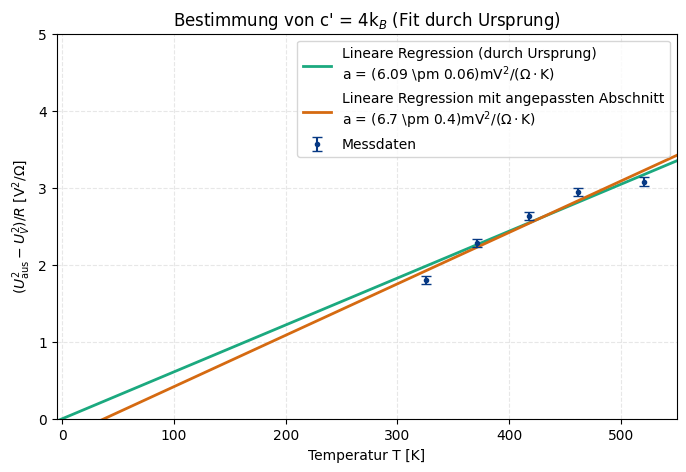

Steigung (durch Ursprung): 0.00609 \pm 0.00006
c' = 4k_B = 0.00609 V^2/(K * Ohm)


In [981]:
aufgabe = '4a'

y_data = U_diff[1:] / R_1
x_data = T_1

popt_origin, pcov_origin = curve_fit(linear, x_data, y_data, sigma=err_U_diff[1:], absolute_sigma=True)
steig_origin = popt_origin[0]
err_steig_origin = np.sqrt(pcov_origin[0, 0])

# Plot the data and the fit
plt.figure(figsize=(8, 5))
x_data_1 = np.linspace(-5, 550, 1000)
plt.plot(
    x_data_1, 
    linear(x_data_1, *popt_origin),
    label=f'Lineare Regression (durch Ursprung)\na = ({pap.round_sig_digs(err_steig_origin * 1e3, steig_origin* 1e3)[2]})' r'mV$^2$/($\Omega \cdot$K)',
    linewidth=2
)

popt, pcov = curve_fit(linear_2, x_data, y_data, sigma=err_U_diff[1:], absolute_sigma=True)
steig = popt[0]
err_steig = np.sqrt(pcov[0, 0])

plt.plot(
    x_data_1, 
    linear_2(x_data_1, *popt),
    label=f'Lineare Regression mit angepassten Abschnitt\na = ({pap.round_sig_digs(err_steig * 1e3, steig * 1e3)[2]})' r'mV$^2$/($\Omega \cdot$K)',
    linewidth=2
)

plt.errorbar(
    x_data, 
    y_data, 
    err_U_diff[1:], 
    label='Messdaten', 
    fmt='.', 
    ls='',
    capsize=3.5
)

plt.xlabel('Temperatur T [K]')
plt.xlim(-5, 550)
plt.ylim(0, 5)

plt.ylabel(r'$(U_{\text{aus}}^2 - U_V^2) / R$ [V$^2$/Ω]')
plt.title('Bestimmung von c\' = 4k$_B$ (Fit durch Ursprung)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.savefig(fr"{plt_save_folder}Fit_durch_Ursprung_{aufgabe}.pdf")
plt.show()

print(f'Steigung (durch Ursprung): {pap.round_sig_digs(err_steig_origin, steig_origin)[2]}')
print(f'c\' = 4k_B = {steig_origin:.3g} V^2/(K * Ohm)')